In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('eval_newcv_newselect/EGFR_MAPK/dream_cytof/evaluate_all_v37.csv')



In [15]:
import pandas as pd
import wandb
from tqdm import tqdm

api = wandb.Api(timeout=50)

runs = api.runs("lab_frohlich/DeepMechanisticModels.v37.dream_cytof")

all_rows = []
for run in tqdm(runs):
    context = run.config.get("context")
    samples = run.config.get("samples")
    n_hidden = run.config.get("n_hidden")
    depth = run.config.get("depth")
    features = run.config.get("features")
    features_selection = run.config.get("features_selection")
    job = run.config.get("job")
    l1reg_inflater_output = run.config.get("l1reg_inflater_output")
    inflater_output_reg_epoch = run.config.get("inflater_output_reg_epoch")
    l2reg_inflater_output = run.config.get("l2reg_inflater_output")
    sparse_threshold_perc = run.config.get("sparse_threshold_perc")

    try:
        history = run.scan_history(
            keys=["rmse_train", "rmse_val", "_step"],
        )
    except Exception as e:
        print(f"Skipping run {run.id} due to error: {e}")
        continue

    for row in history:
        if row.get("rmse_train") is not None and row.get("rmse_val") is not None:
            all_rows.append({
                # Config
                "context": context,
                "samples": samples,
                "n_hidden": n_hidden,
                "depth": depth,
                "features": features,
                "features_selection": features_selection,
                "job": job,
                "l1reg_inflater_output": l1reg_inflater_output,
                "inflater_output_reg_epoch": inflater_output_reg_epoch,
                "l2reg_inflater_output": l2reg_inflater_output,
                "sparse_threshold_perc": sparse_threshold_perc,
                # Epoch
                "step": row["_step"],
                # RMSEs
                "rmse_train": row["rmse_train"],
                "rmse_val": row["rmse_val"],
            })

results_df = pd.DataFrame(all_rows)
results_df.to_csv("results_feature_selection_v37.csv", index=False)

100%|██████████| 2775/2775 [34:34<00:00,  1.34it/s]  


In [16]:
df = pd.read_csv("results_feature_selection_v37.csv")
results_df.head()

,context,samples,n_hidden,depth,features,features_selection,job,l1reg_inflater_output,inflater_output_reg_epoch,l2reg_inflater_output,sparse_threshold_perc,step,rmse_train,rmse_val
0,proteomics,1of5,2,0,HVGRFE_15_tree,None,0,100,100,0,gmm,1,0.522207,0.879438
1,proteomics,1of5,2,0,HVGRFE_15_tree,None,0,100,100,0,gmm,13,0.489958,0.850063
2,proteomics,1of5,2,0,HVGRFE_15_tree,None,0,100,100,0,gmm,26,0.477073,0.791140
3,proteomics,1of5,2,0,HVGRFE_15_tree,None,0,100,100,0,gmm,36,0.462681,0.732323
4,proteomics,1of5,2,0,HVGRFE_15_tree,None,0,100,100,0,gmm,50,0.453407,0.731374


In [17]:
order = df[df['step']==499][['features', 'rmse_val']].groupby(['features']).aggregate(
    {'rmse_val': 'mean'}).sort_values('rmse_val').index.tolist()
order

['HVGRFE_15_permute',
 'HVGRFE_10_permute',
 'HVGRFE_15_tree',
 'HVGRFE_5_tree',
 'HVGRFE_5_permute',
 'HVGRFE_20_tree',
 'MPAS',
 'HVGRFE_10_tree',
 'HVGRFE_20_permute',
 'RFE_5_permute',
 'MSIGDB_PID_MAPK',
 'IHC',
 'RFE_5_tree',
 'RFE_15_permute',
 'CompRes',
 'MSIGDB_PID_P38',
 'CSC',
 'MSIGDB_REACTOME_EGFR_DOWNREGULATION',
 'RFE_20_permute',
 'MSIGDB_BIOCARTA_ERK',
 'RFE_20_tree',
 'RFE_10_permute',
 'RFE_10_tree',
 'MSIGDB_KEGG_ERK',
 'MSIGDB_WP_P38',
 'MSIGDB_REACTOME_ERBB2',
 'RFE_15_tree',
 'MSIGDB_PID_ERBB_DOWNSTREAM',
 'MSIGDB_REACTOME_MAPK',
 'MSIGDB_REACTOME_ERBB2_CANCER',
 'MSIGDB_KEGG_EGFR',
 'MSIGDB_KEGG_RTK',
 'MSIGDB_REACTOME_ERBB2_OVEREXPRESSION',
 'MSIGDB_PID_P38_DOWNSTREAM',
 'MSIGDB_BIOCARTA_EGF',
 'MEKFA',
 'MSIGDB_REACTOME_EGFR_CANCER_VARIANTS',
 'MSIGDB_BIOCARTA_RAS',
 'MSIGDB_BIOCARTA_P38',
 'MSIGDB_REACTOME_P38',
 'MSIGDB_REACTOME_EGFR_CANCER',
 'MSIGDB_REACTOME_EGFR',
 'PAM50',
 'MSIGDB_WP_EGFR',
 'MSIGDB_BIOCARTA_MAPK',
 'MSIGDB_REACTOME_ERK_TARGETS',
 'MSI

In [37]:
order_tx = {
    c: df.loc[(df['step']==499) & (df['context'] == c),['features', 'rmse_val']].groupby(['features']).aggregate(
    {'rmse_val': 'mean'}).sort_values('rmse_val').index.tolist()
    for c in ['transcriptomics', 'proteomics']
}
order_tx

{'transcriptomics': ['HVGRFE_10_permute',
  'HVGRFE_15_permute',
  'HVGRFE_15_tree',
  'MSIGDB_PID_MAPK',
  'HVGRFE_20_permute',
  'HVGRFE_5_tree',
  'HVGRFE_20_tree',
  'HVGRFE_10_tree',
  'MPAS',
  'MSIGDB_KEGG_ERK',
  'HVGRFE_5_permute',
  'MSIGDB_REACTOME_EGFR_CANCER_VARIANTS',
  'CompRes',
  'MSIGDB_REACTOME_EGFR_DOWNREGULATION',
  'MSIGDB_REACTOME_EGFR_CANCER',
  'MSIGDB_REACTOME_ERBB2_CANCER',
  'MSIGDB_REACTOME_ERK_TARGETS',
  'MSIGDB_KEGG_ERBB',
  'MSIGDB_BIOCARTA_ERK',
  'MSIGDB_PID_ERBB_PROXIMAL',
  'RFE_15_tree',
  'RFE_5_tree',
  'MSIGDB_BIOCARTA_EGF',
  'PAM50',
  'RFE_5_permute',
  'MSIGDB_BIOCARTA_RAS',
  'RFE_10_permute',
  'MSIGDB_WP_P38',
  'IHC',
  'RFE_20_tree',
  'RFE_10_tree',
  'MSIGDB_WP_EGFR_RESISTANCE',
  'MSIGDB_BIOCARTA_MAPK',
  'MSIGDB_PID_ERBB_DOWNSTREAM',
  'MSIGDB_KEGG_MAPK',
  'MSIGDB_REACTOME_MAPK_CANCER',
  'MSIGDB_WP_EGFR',
  'MSIGDB_REACTOME_MAPK',
  'MSIGDB_WP_MAPK',
  'MSIGDB_PID_ERBB',
  'MSIGDB_KEGG_EGFR',
  'RFE_20_permute',
  'RFE_15_permute'

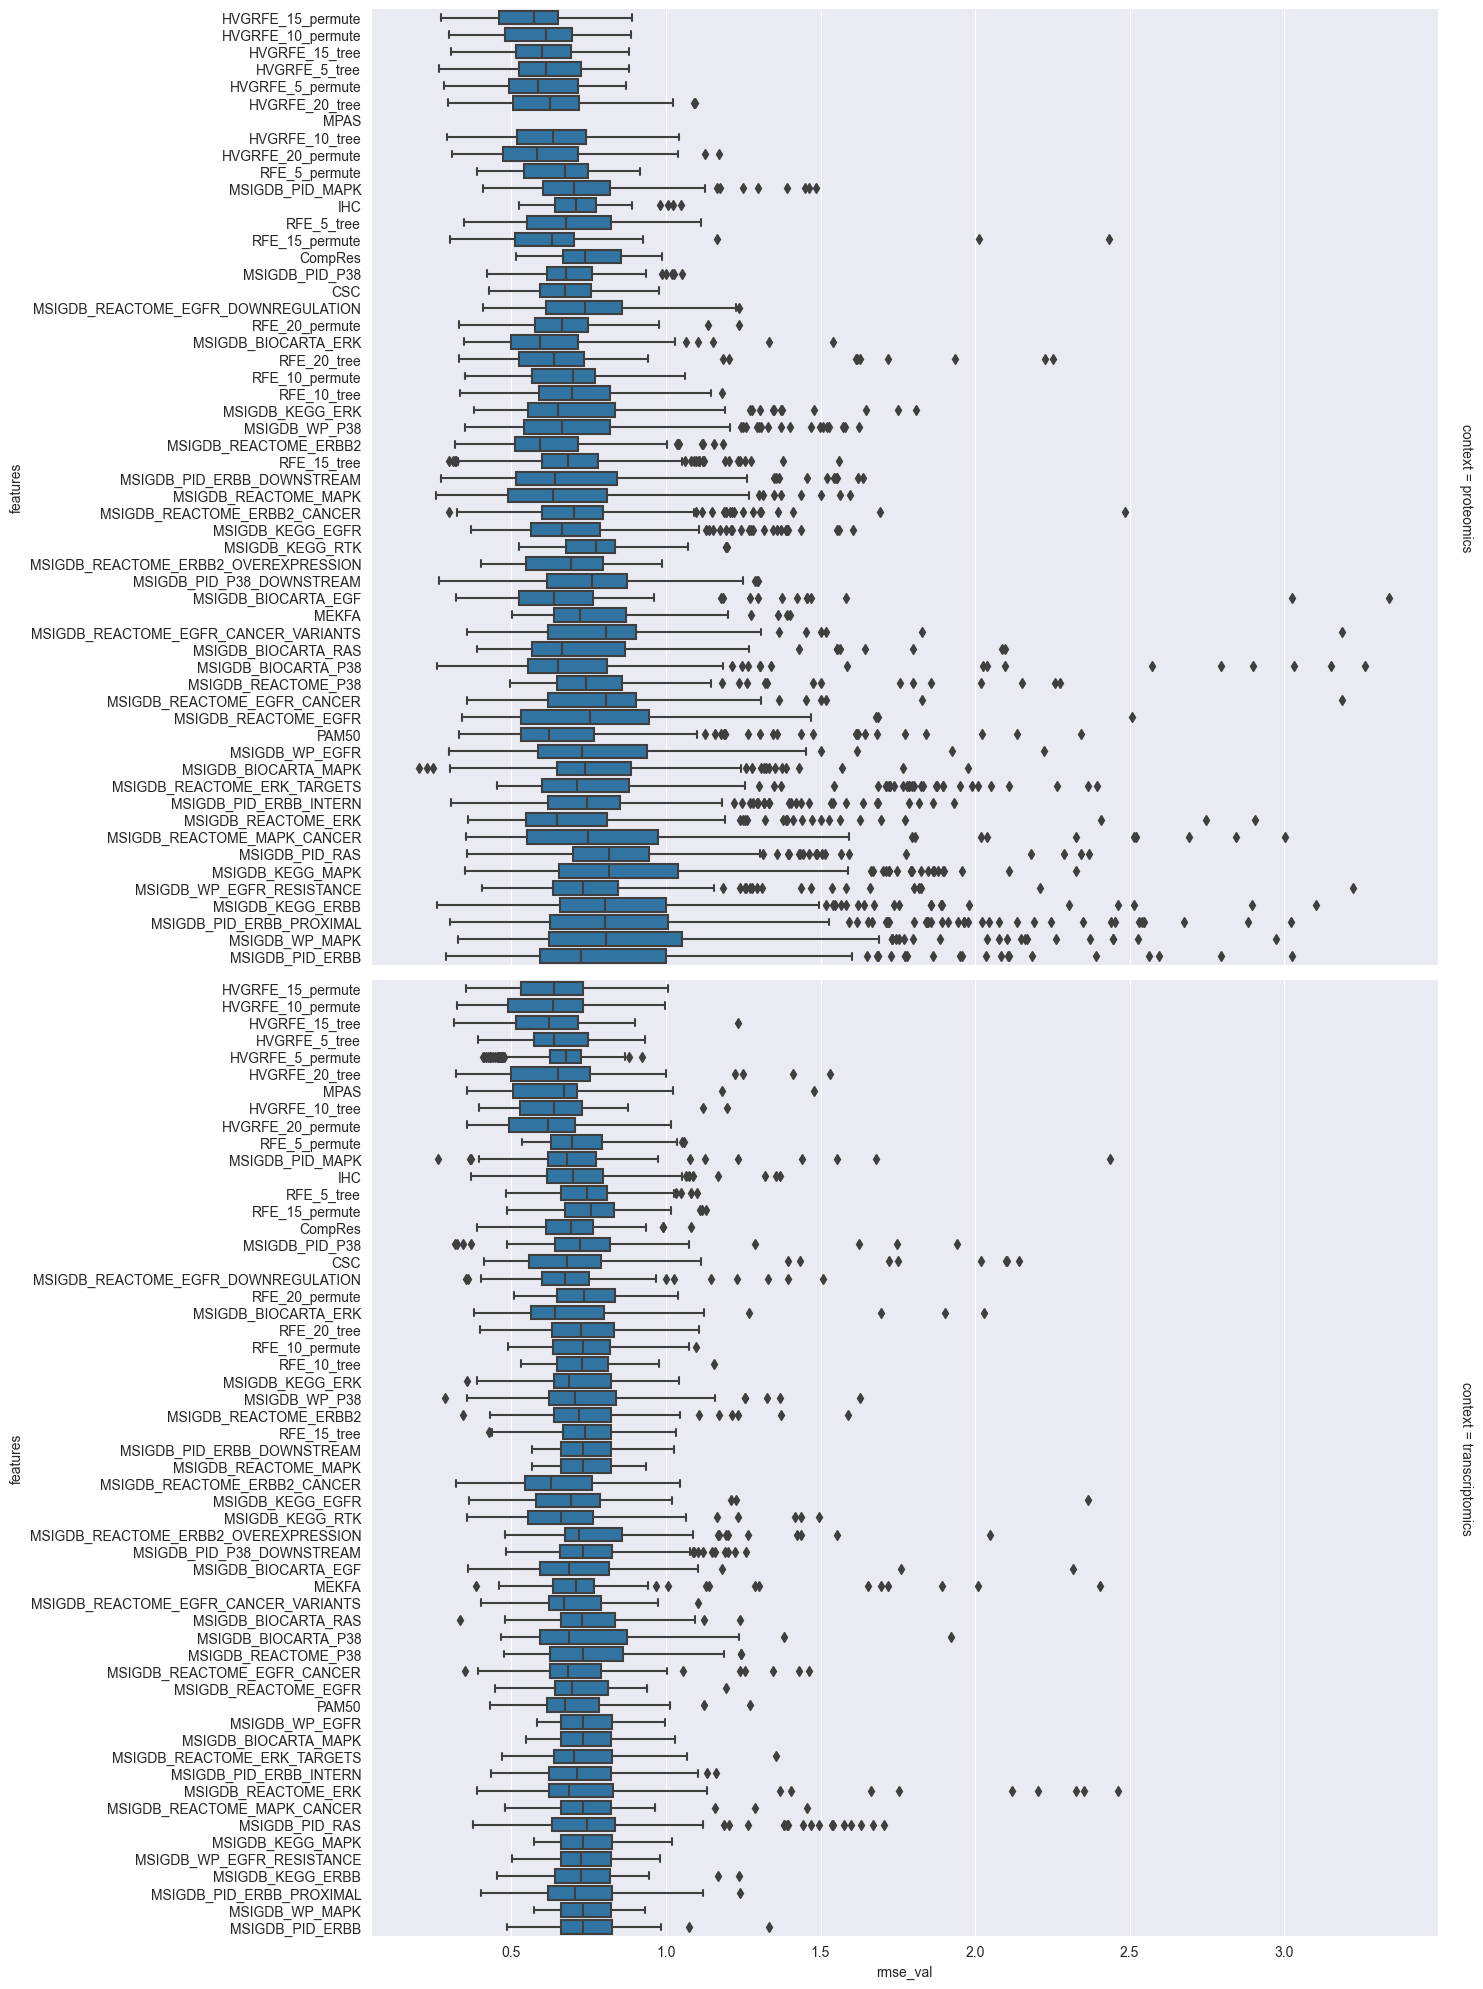

In [20]:
g = sns.FacetGrid(
    df,
    row='context',
    margin_titles=True,
    sharey=True,
    sharex=True,
    height=10,
    aspect=1.5
)
g.map_dataframe(
    sns.boxplot,
    y='features',
    x='rmse_val',
    order=order,
)
plt.show()

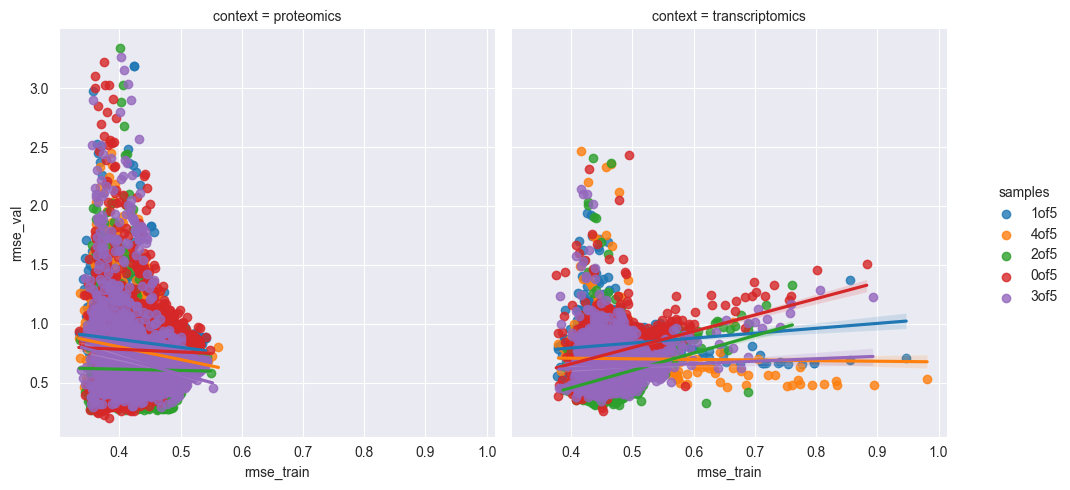

In [40]:
sns.lmplot(
    data=df,
    x='rmse_train',
    y='rmse_val',
    hue='samples',
    col='context',
    height=5,
    aspect=1,
    facet_kws={'margin_titles': True, 'sharey': True, 'sharex': True},
)

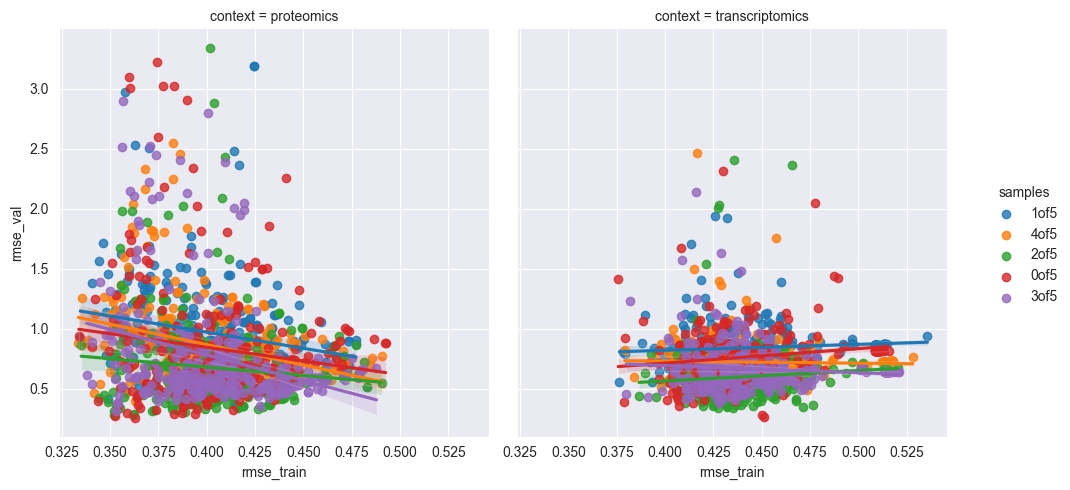

In [39]:
sns.lmplot(
    data=df[(df['rmse_train'] < 0.55) & (df['step'] == 499)],
    x='rmse_train',
    y='rmse_val',
    hue='samples',
    col='context',
    height=5,
    aspect=1,
    facet_kws={'margin_titles': True, 'sharey': True, 'sharex': True},
)

In [29]:

df[(df['rmse_train'] > 0.55) & (df['step'] == 499)]

,context,samples,n_hidden,depth,features,features_selection,job,l1reg_inflater_output,inflater_output_reg_epoch,l2reg_inflater_output,sparse_threshold_perc,step,rmse_train,rmse_val
3347,transcriptomics,4of5,2,0,PAM50,NaN,2,100,100,0,gmm,499,0.664987,1.013481
15287,transcriptomics,1of5,2,0,MSIGDB_REACTOME_ERBB2,NaN,4,100,100,0,gmm,499,0.855416,1.372494
20603,transcriptomics,2of5,2,0,MSIGDB_REACTOME_EGFR_CANCER,NaN,3,100,100,0,gmm,499,0.688703,0.426462
24503,transcriptomics,0of5,2,0,MSIGDB_REACTOME_ERK,NaN,1,100,100,0,gmm,499,0.586432,0.471600
24707,transcriptomics,2of5,2,0,MSIGDB_BIOCARTA_RAS,NaN,1,100,100,0,gmm,499,0.620872,0.333229


In [44]:
df_sub = df[df.features.str.startswith(('HVG', 'RFE')) & (df.step == df.step.max())].copy()
df_sub

,context,samples,n_hidden,depth,features,features_selection,job,l1reg_inflater_output,inflater_output_reg_epoch,l2reg_inflater_output,sparse_threshold_perc,step,rmse_train,rmse_val
11,proteomics,1of5,2,0,HVGRFE_15_tree,NaN,0,100,100,0,gmm,499,0.396865,0.623437
23,proteomics,4of5,2,0,HVGRFE_10_permute,NaN,0,100,100,0,gmm,499,0.393569,0.764516
47,proteomics,0of5,2,0,RFE_15_tree,NaN,3,100,100,0,gmm,499,0.393400,0.605071
71,transcriptomics,1of5,2,0,HVGRFE_15_tree,NaN,1,100,100,0,gmm,499,0.416135,0.656202
95,proteomics,0of5,2,0,HVGRFE_5_permute,NaN,2,100,100,0,gmm,499,0.439829,0.586309
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33251,transcriptomics,3of5,2,0,RFE_15_permute,NaN,3,100,100,0,gmm,499,0.430854,0.722231
33263,transcriptomics,3of5,2,0,RFE_15_permute,NaN,4,100,100,0,gmm,499,0.435548,0.954440
33275,transcriptomics,3of5,2,0,RFE_15_permute,NaN,1,100,100,0,gmm,499,0.425740,1.129433
33287,transcriptomics,3of5,2,0,RFE_15_permute,NaN,0,100,100,0,gmm,499,0.440904,0.899678


In [49]:
df_sub['n_features'] = df_sub['features'].apply(lambda x: int(x.split('_')[1]))
df_sub['method'] = df_sub['features'].apply(lambda x: x.split('_')[0] + '_' + x.split('_')[2])

/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/

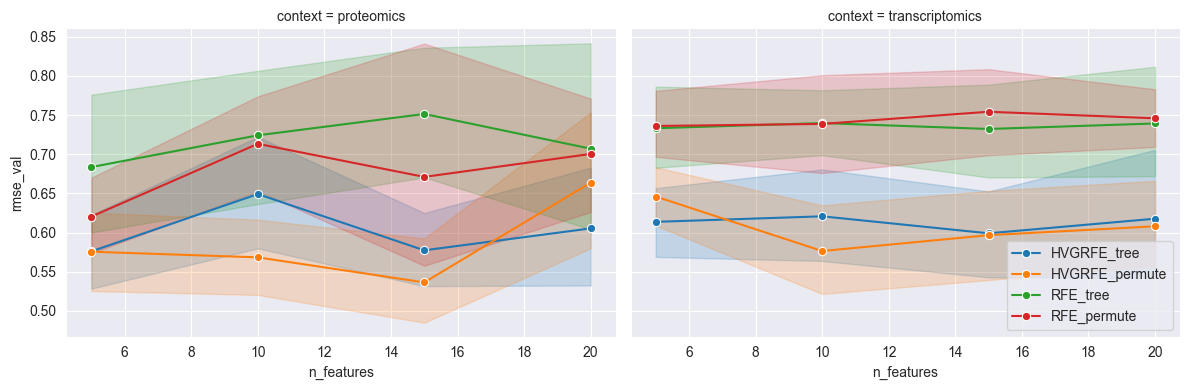

In [50]:
g = sns.FacetGrid(
    df_sub,
    col="context",
    hue="method",
    height=4,
    aspect=1.5
)
g.map_dataframe(
    sns.lineplot,
    x="n_features",
    y="rmse_val",
    marker="o",
    dashes=False
)
plt.legend()

In [54]:
import numpy as np
df_sub

,context,samples,n_hidden,depth,features,features_selection,job,l1reg_inflater_output,inflater_output_reg_epoch,l2reg_inflater_output,sparse_threshold_perc,step,rmse_train,rmse_val,n_features,baseline,method
11,proteomics,1of5,2,0,HVGRFE_15_tree,NaN,0,100,100,0,gmm,499,0.396865,0.623437,15,HVGRFE,HVGRFE_tree
23,proteomics,4of5,2,0,HVGRFE_10_permute,NaN,0,100,100,0,gmm,499,0.393569,0.764516,10,HVGRFE,HVGRFE_permute
47,proteomics,0of5,2,0,RFE_15_tree,NaN,3,100,100,0,gmm,499,0.393400,0.605071,15,RFE,RFE_tree
71,transcriptomics,1of5,2,0,HVGRFE_15_tree,NaN,1,100,100,0,gmm,499,0.416135,0.656202,15,HVGRFE,HVGRFE_tree
95,proteomics,0of5,2,0,HVGRFE_5_permute,NaN,2,100,100,0,gmm,499,0.439829,0.586309,5,HVGRFE,HVGRFE_permute
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33251,transcriptomics,3of5,2,0,RFE_15_permute,NaN,3,100,100,0,gmm,499,0.430854,0.722231,15,RFE,RFE_permute
33263,transcriptomics,3of5,2,0,RFE_15_permute,NaN,4,100,100,0,gmm,499,0.435548,0.954440,15,RFE,RFE_permute
33275,transcriptomics,3of5,2,0,RFE_15_permute,NaN,1,100,100,0,gmm,499,0.425740,1.129433,15,RFE,RFE_permute
33287,transcriptomics,3of5,2,0,RFE_15_permute,NaN,0,100,100,0,gmm,499,0.440904,0.899678,15,RFE,RFE_permute
